In [ ]:
import os

dataset_path = '/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/dataset'

os.listdir(dataset_path)

['train', 'test']

Starting the Pre Processing Stage

We will be applying CLAHE


CLAHE = Contrast Limited Adaptive Histogram Equalization

It:

Enhances local contrast. </br>
Makes cell boundaries/nucleus clearer. </br>
Avoids over-amplifying noise.

In [7]:
import os
import cv2
import numpy as np
from tqdm import tqdm


# Setting up paths

base_path = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/dataset"

train_path = os.path.join(base_path, "train")
test_path = os.path.join(base_path, "test")

output_base = "/content/drive/MyDrive/leukocyte-classification-cnn-transfer-learning/clahe_dataset"

output_train = os.path.join(output_base, "train")
output_test = os.path.join(output_base, "test")

Using the same CLAHE Parameters from the Research Paper
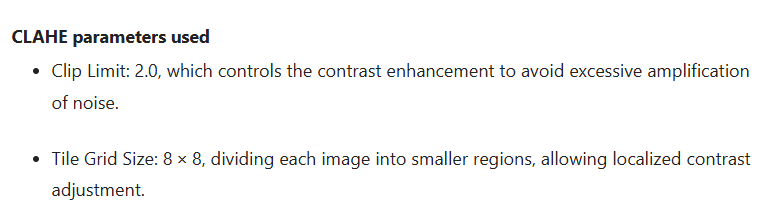

In [9]:
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8)
)



# CLAHE Function

def apply_clahe(input_folder, output_folder):

    classes = os.listdir(input_folder)

    for cls in classes:

        input_cls_path = os.path.join(input_folder, cls)
        output_cls_path = os.path.join(output_folder, cls)

        os.makedirs(output_cls_path, exist_ok=True)

        images = os.listdir(input_cls_path)

        for img_name in tqdm(images):

            img_path = os.path.join(input_cls_path, img_name)

            # Read image
            img = cv2.imread(img_path)

            # Convert BGR → LAB
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

            l, a, b = cv2.split(lab)

            # Apply CLAHE on L channel
            cl = clahe.apply(l)

            merged = cv2.merge((cl, a, b))

            # Convert back to RGB
            final_img = cv2.cvtColor(merged, cv2.COLOR_LAB2BGR)

            # Save image
            save_path = os.path.join(output_cls_path, img_name)

            cv2.imwrite(save_path, final_img)


# Applying


apply_clahe(train_path, output_train)
apply_clahe(test_path, output_test)


100%|██████████| 100/100 [00:03<00:00, 26.59it/s]
